<a href="https://colab.research.google.com/github/santhroshan/3D-Color-segementation-to-detect-Diabetic-Retinopathy/blob/main/3D_Color_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the Excel file containing the disease data.


Saving DATASETS.xlsx to DATASETS (1).xlsx
Do you want to upload an image? (yes/no): yes
Please upload the 2D OCTA image.


Saving 10004.bmp to 10004.bmp


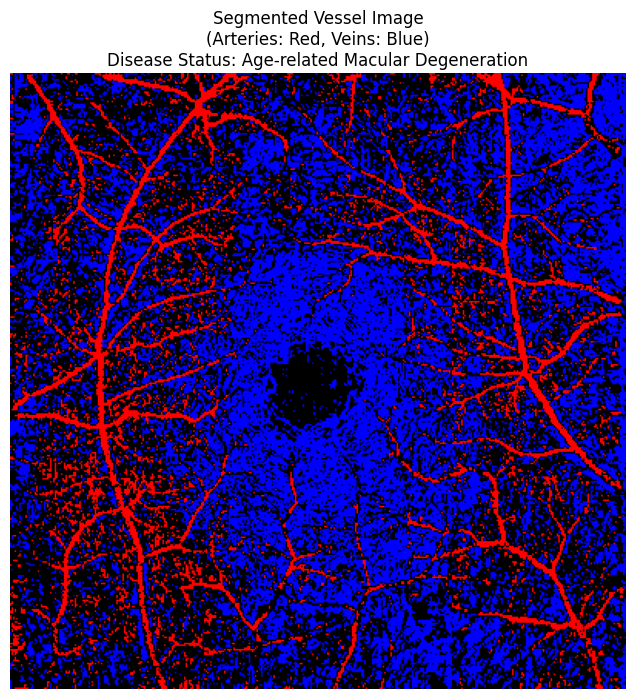

Do you want to upload an image? (yes/no): yes
Please upload the 2D OCTA image.


Saving 10005.bmp to 10005.bmp


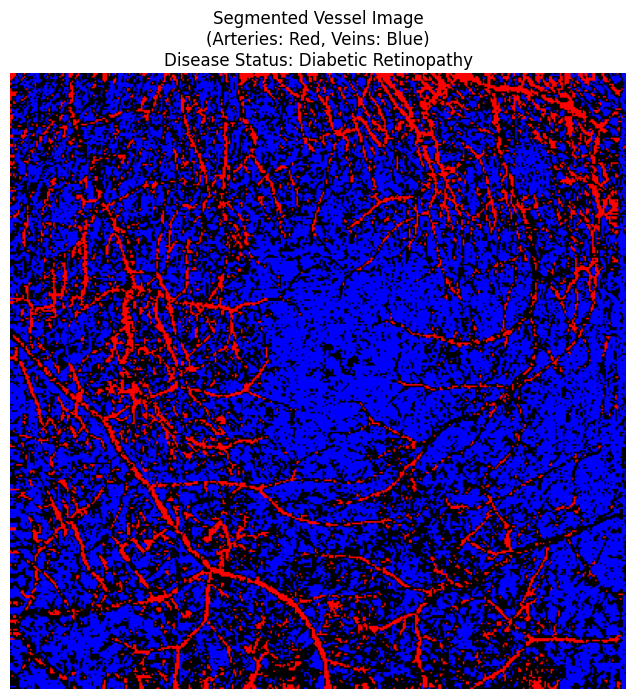

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2
import pandas as pd
import re

print("Please upload the Excel file containing the disease data.")
uploaded_excel = files.upload()

excel_filename = list(uploaded_excel.keys())[0]

df = pd.read_excel(excel_filename)

while True:
    choice = input("Do you want to upload an image? (yes/no): ").strip().lower()
    if choice != 'yes':
        print("Exiting the program.")
        break

    print("Please upload the 2D OCTA image.")
    uploaded_image = files.upload()

    image_filename = list(uploaded_image.keys())[0]

    match = re.search(r'\d+', image_filename)
    if match:
        image_id = int(match.group())
    else:
        print("Invalid image filename format. Skipping...")
        continue

    disease_status = df.loc[df['ID'] == image_id, 'Disease'].values
    if len(disease_status) > 0:
        disease_status = disease_status[0]
    else:
        disease_status = "Unknown"

    image = Image.open(image_filename).convert('L')
    image = np.array(image)

    normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

    arteries = cv2.inRange(normalized, 180, 255)
    veins = cv2.inRange(normalized, 30, 100)

    segmented_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    segmented_image[arteries > 0] = [255, 0, 0]
    segmented_image[veins > 0] = [0, 0, 255]

    plt.figure(figsize=(8, 8))
    plt.imshow(segmented_image)
    plt.title(f'Segmented Vessel Image\n(Arteries: Red, Veins: Blue)\nDisease Status: {disease_status}')
    plt.axis('off')
    plt.show()